In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sbcbinaryformat import Streamer, Writer
import sys
sys.path.append('/exp/e961/app/users/zsheng')
from SBC_Analysis.DataHandling import ReadBinary

Processing run 0 ...
(1, 1000001, 8)
hellp
1000001 8


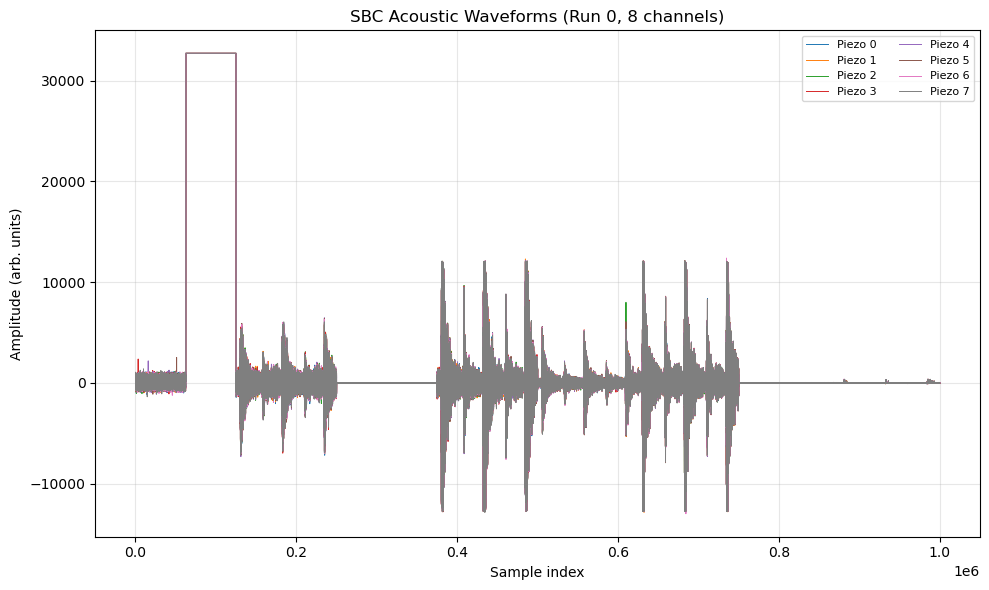

  Run 0: saved
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_waveforms_run0.png
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_fft_run0.png

Processing run 1 ...
(1, 1000001, 8)
hellp
1000001 8


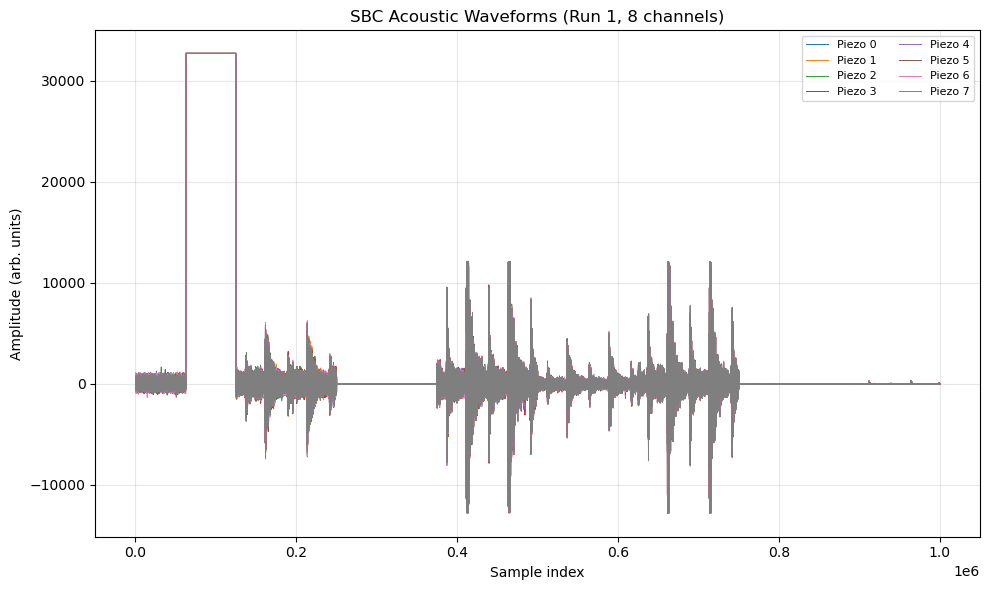

  Run 1: saved
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_waveforms_run1.png
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_fft_run1.png

Processing run 2 ...
(1, 1000001, 8)
hellp
1000001 8


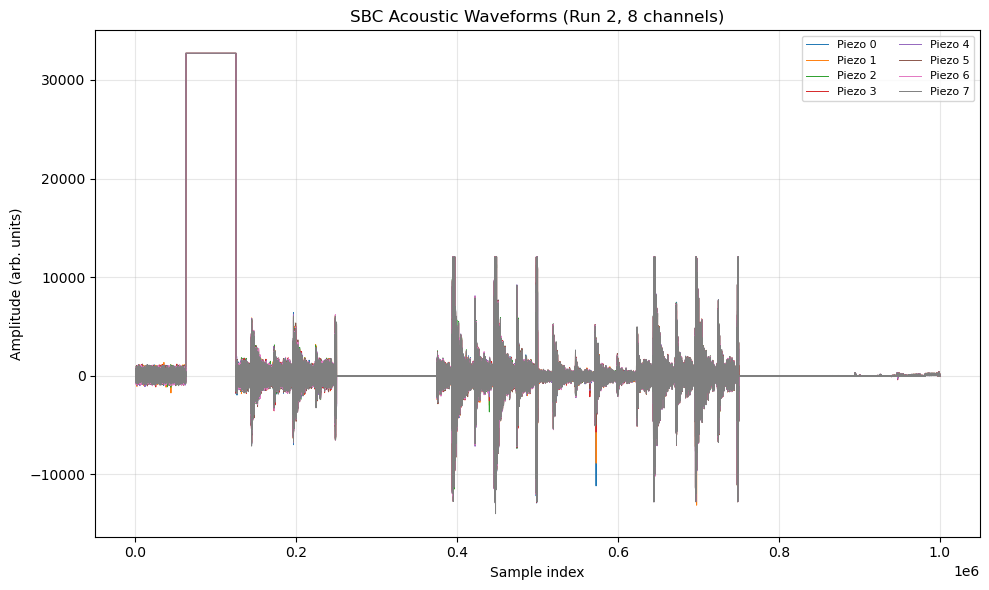

  Run 2: saved
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_waveforms_run2.png
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_fft_run2.png

Processing run 3 ...
(1, 1000001, 8)
hellp
1000001 8


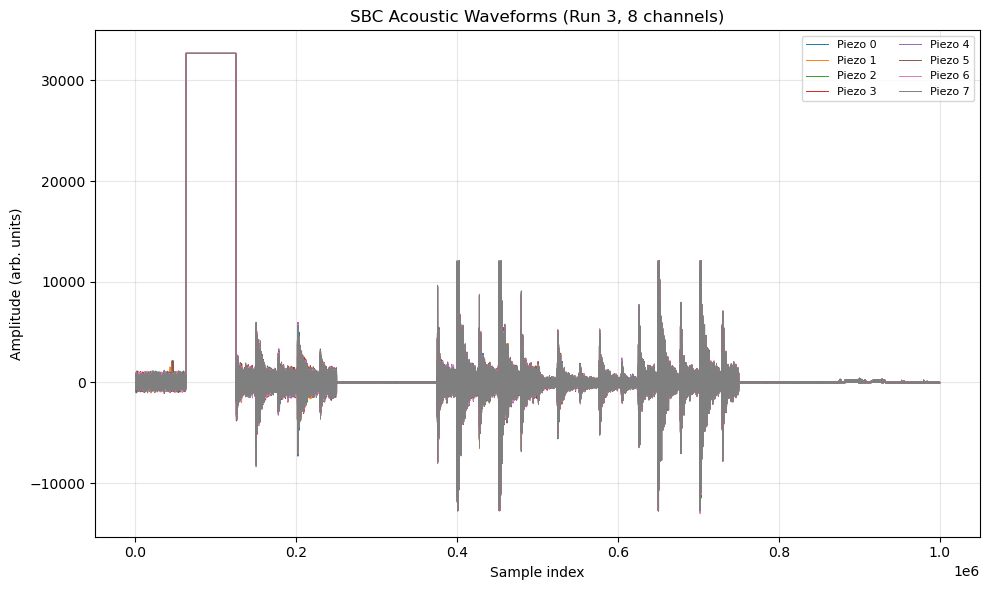

  Run 3: saved
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_waveforms_run3.png
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_fft_run3.png

Processing run 4 ...
(1, 1000001, 8)
hellp
1000001 8


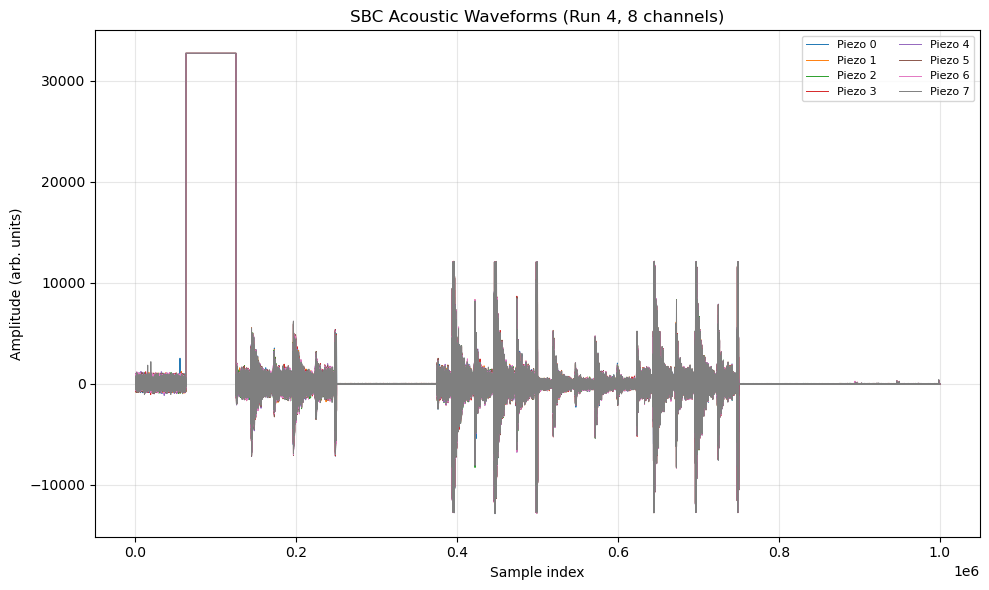

  Run 4: saved
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_waveforms_run4.png
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_fft_run4.png

Processing run 5 ...
(1, 1000001, 8)
hellp
1000001 8


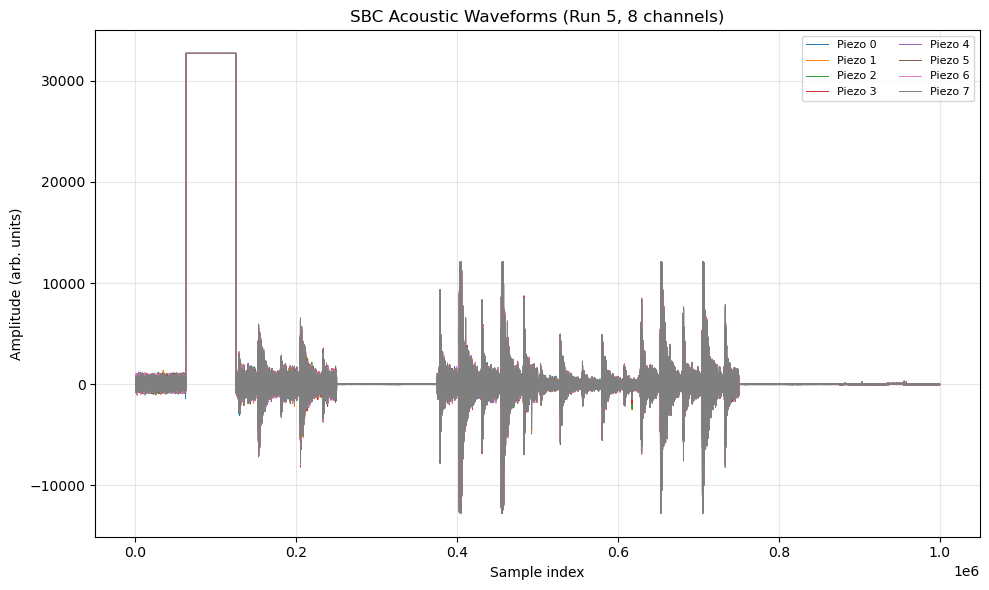

  Run 5: saved
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_waveforms_run5.png
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_fft_run5.png

Processing run 6 ...
(1, 1000001, 8)
hellp
1000001 8


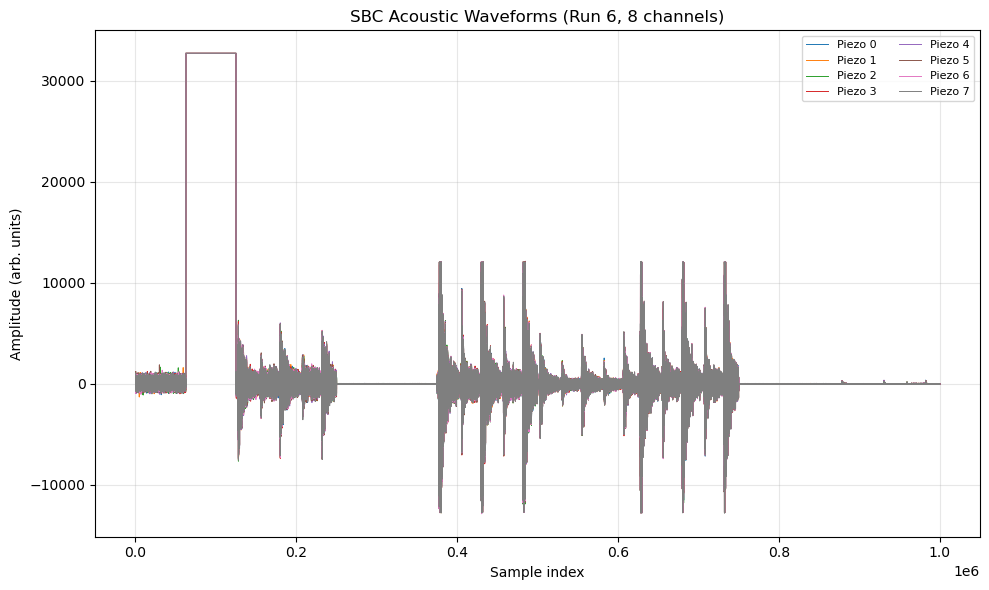

  Run 6: saved
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_waveforms_run6.png
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_fft_run6.png

Processing run 7 ...
(1, 1000001, 8)
hellp
1000001 8


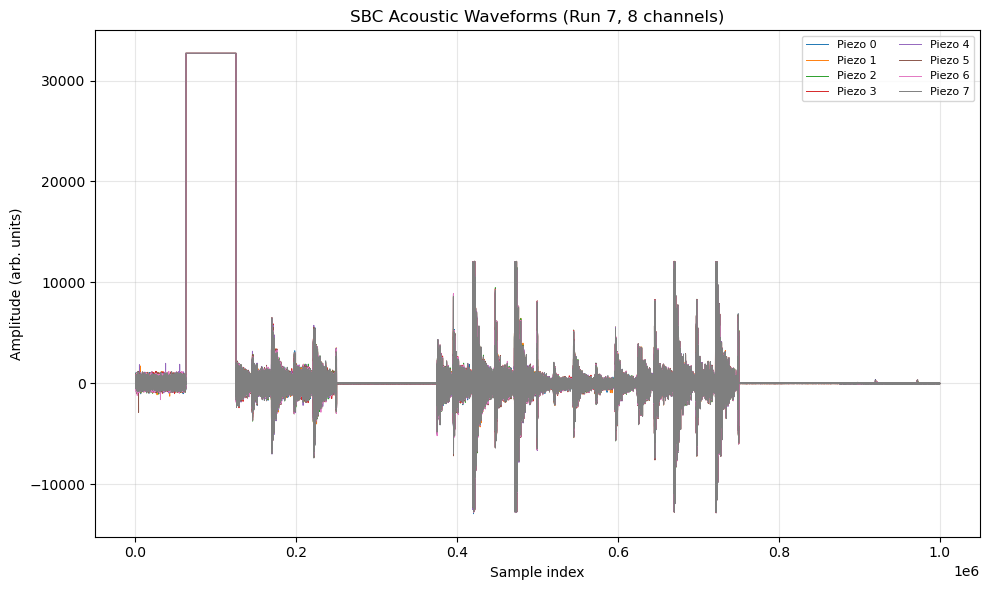

  Run 7: saved
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_waveforms_run7.png
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_fft_run7.png

Processing run 8 ...
(1, 1000001, 8)
hellp
1000001 8


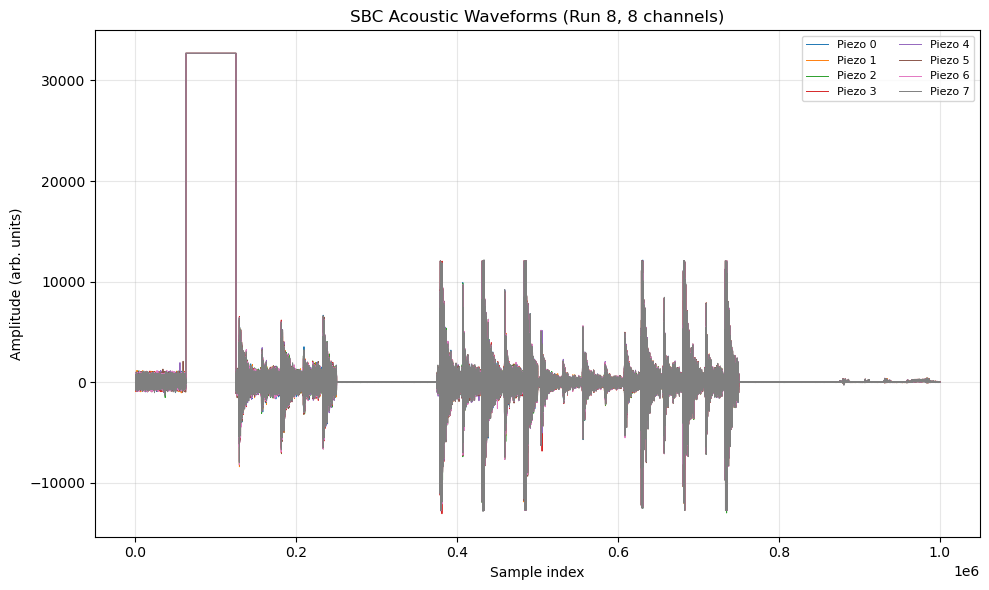

  Run 8: saved
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_waveforms_run8.png
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_fft_run8.png

Processing run 9 ...
(1, 1000001, 8)
hellp
1000001 8


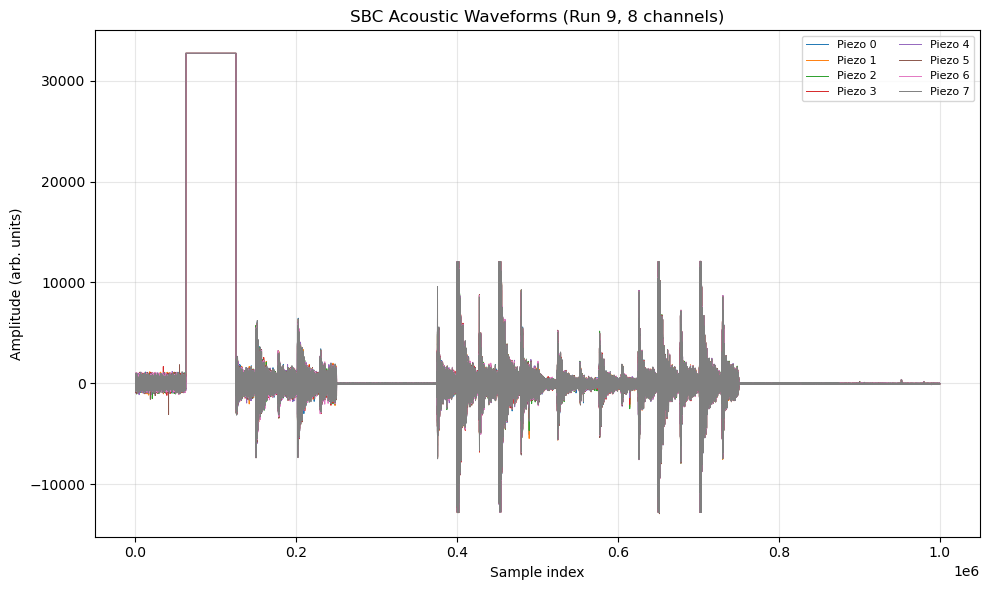

  Run 9: saved
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_waveforms_run9.png
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_fft_run9.png

Processing run 10 ...
(1, 1000001, 8)
hellp
1000001 8


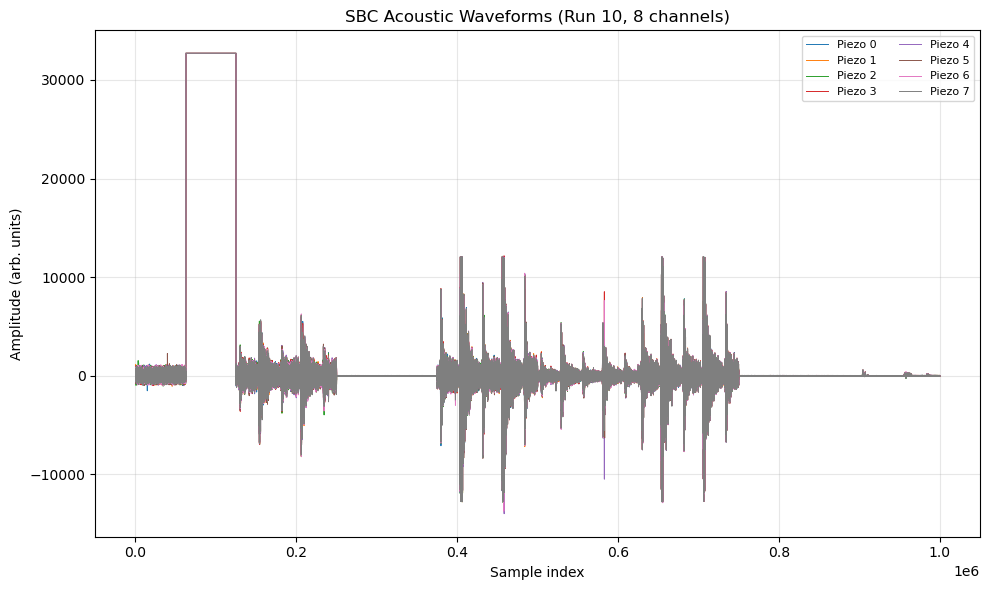

  Run 10: saved
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_waveforms_run10.png
   /exp/e961/app/users/zsheng/reconstructed_20251007_0/acoustic_fft_run10.png


 All requested runs processed successfully.
Outputs in:
/exp/e961/app/users/zsheng/reconstructed_20251007_0


In [2]:
base_dir = "/exp/e961/data/SBC-25-daqdata/20251007_0"
out_dir  = "/exp/e961/app/users/zsheng/reconstructed_20251007_0"
sample_rate = 1.0e6   # Hz (≈1 MHz)
run_range = range(0, 11)  # 0 → 10
os.makedirs(out_dir, exist_ok=True)
for run in run_range:
    run_path = os.path.join(base_dir, str(run))
    acoustic_file = os.path.join(run_path, "acoustics.sbc")
    if not os.path.exists(acoustic_file):
        print(f"  Run {run}: missing {acoustic_file}, skipping")
        continue
    print(f"Processing run {run} ...")
    try:
        acoustic_data = ReadBinary.ReadBlock(acoustic_file)
        print(acoustic_data["Waveforms"].shape)
        waveforms = np.squeeze(acoustic_data["Waveforms"])
        waveforms = waveforms[:, :1000]
        if waveforms.ndim == 1:
            waveforms = waveforms[:, np.newaxis]
        print("hellp")
        n_samples, n_channels = waveforms.shape
        print(n_samples, n_channels)
    except Exception as e:
        print(f" Run {run}: could not read {acoustic_file} → {e}")
        continue
    plt.figure(figsize=(10,6))
    for i in range(n_channels):
        plt.plot(waveforms[:, i], lw=0.7, label=f"Piezo {i}")
    plt.title(f"SBC Acoustic Waveforms (Run {run}, {n_channels} channels)")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude (arb. units)")
    plt.legend(ncol=2, fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    wf_out = os.path.join(out_dir, f"acoustic_waveforms_run{run}.png")
    plt.savefig(wf_out, dpi=200)
    plt.show()
    plt.close()
    freqs = np.fft.rfftfreq(n_samples, d=1/sample_rate)
    plt.figure(figsize=(10,6))
    for i in range(n_channels):
        spec = np.abs(np.fft.rfft(waveforms[:, i]))
        plt.semilogy(freqs, spec, lw=0.7, label=f"Piezo {i}")
    plt.title(f"SBC Acoustic FFT Spectra (Run {run}, {n_channels} channels)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude (log scale)")
    plt.legend(ncol=2, fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    fft_out = os.path.join(out_dir, f"acoustic_fft_run{run}.png")
    plt.savefig(fft_out, dpi=200)
    plt.close()
    print(f"  Run {run}: saved\n   {wf_out}\n   {fft_out}\n")
print("\n All requested runs processed successfully.\nOutputs in:")
print(out_dir)